#Import

In [8]:
import cv2
import os
import random
import numpy as np
import uuid
from PIL import Image
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, Dense, MaxPooling2D, Input, Flatten
from tensorflow.keras.metrics import Precision, Recall

#Load Dataset

In [9]:
PINS_DIR = '/content/drive/MyDrive/face/105_classes_pins_dataset'

if not os.path.exists(PINS_DIR):
  raise ValueError(f"Path not found! Please check the folder name in Google Drive: {PINS_DIR}")

print("Connected to Dataset Directory successfully!")
print("Total classes (persons) found:", len([d for d in os.listdir(PINS_DIR) if os.path.isdir(os.path.join(PINS_DIR, d))]))


Connected to Dataset Directory successfully!
Total classes (persons) found: 105


In [15]:
counts = list(class_counts.values())

print("Max images in a class:", max(counts))
print("Min images in a class:", min(counts))
print("Average images per class:", sum(counts)/len(counts))

Max images in a class: 237
Min images in a class: 86
Average images per class: 166.9904761904762


#Data Visualization

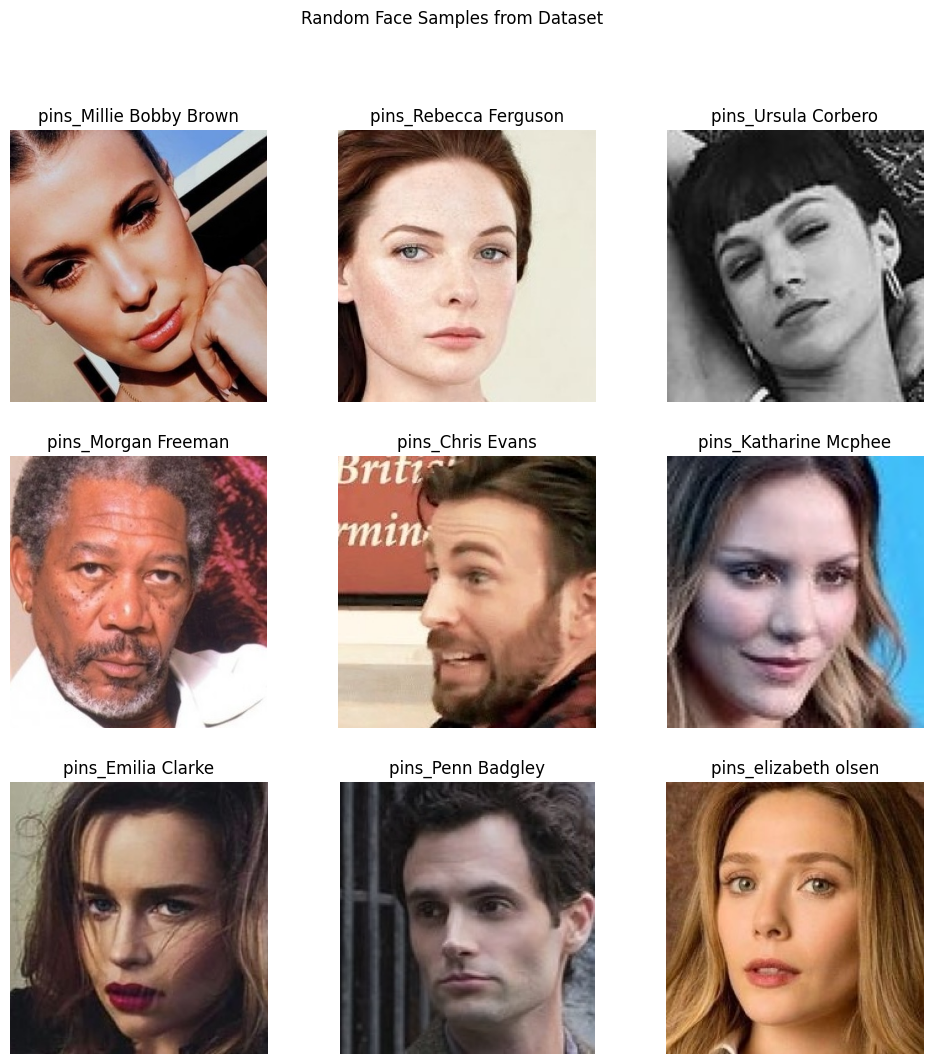

In [10]:
plt.figure(figsize=(12,12))

classes = os.listdir(PINS_DIR)

for i in range(9):
    cls = random.choice(classes)
    img_name = random.choice(os.listdir(os.path.join(PINS_DIR, cls)))
    img_path = os.path.join(PINS_DIR, cls, img_name)

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Random Face Samples from Dataset")
plt.show()

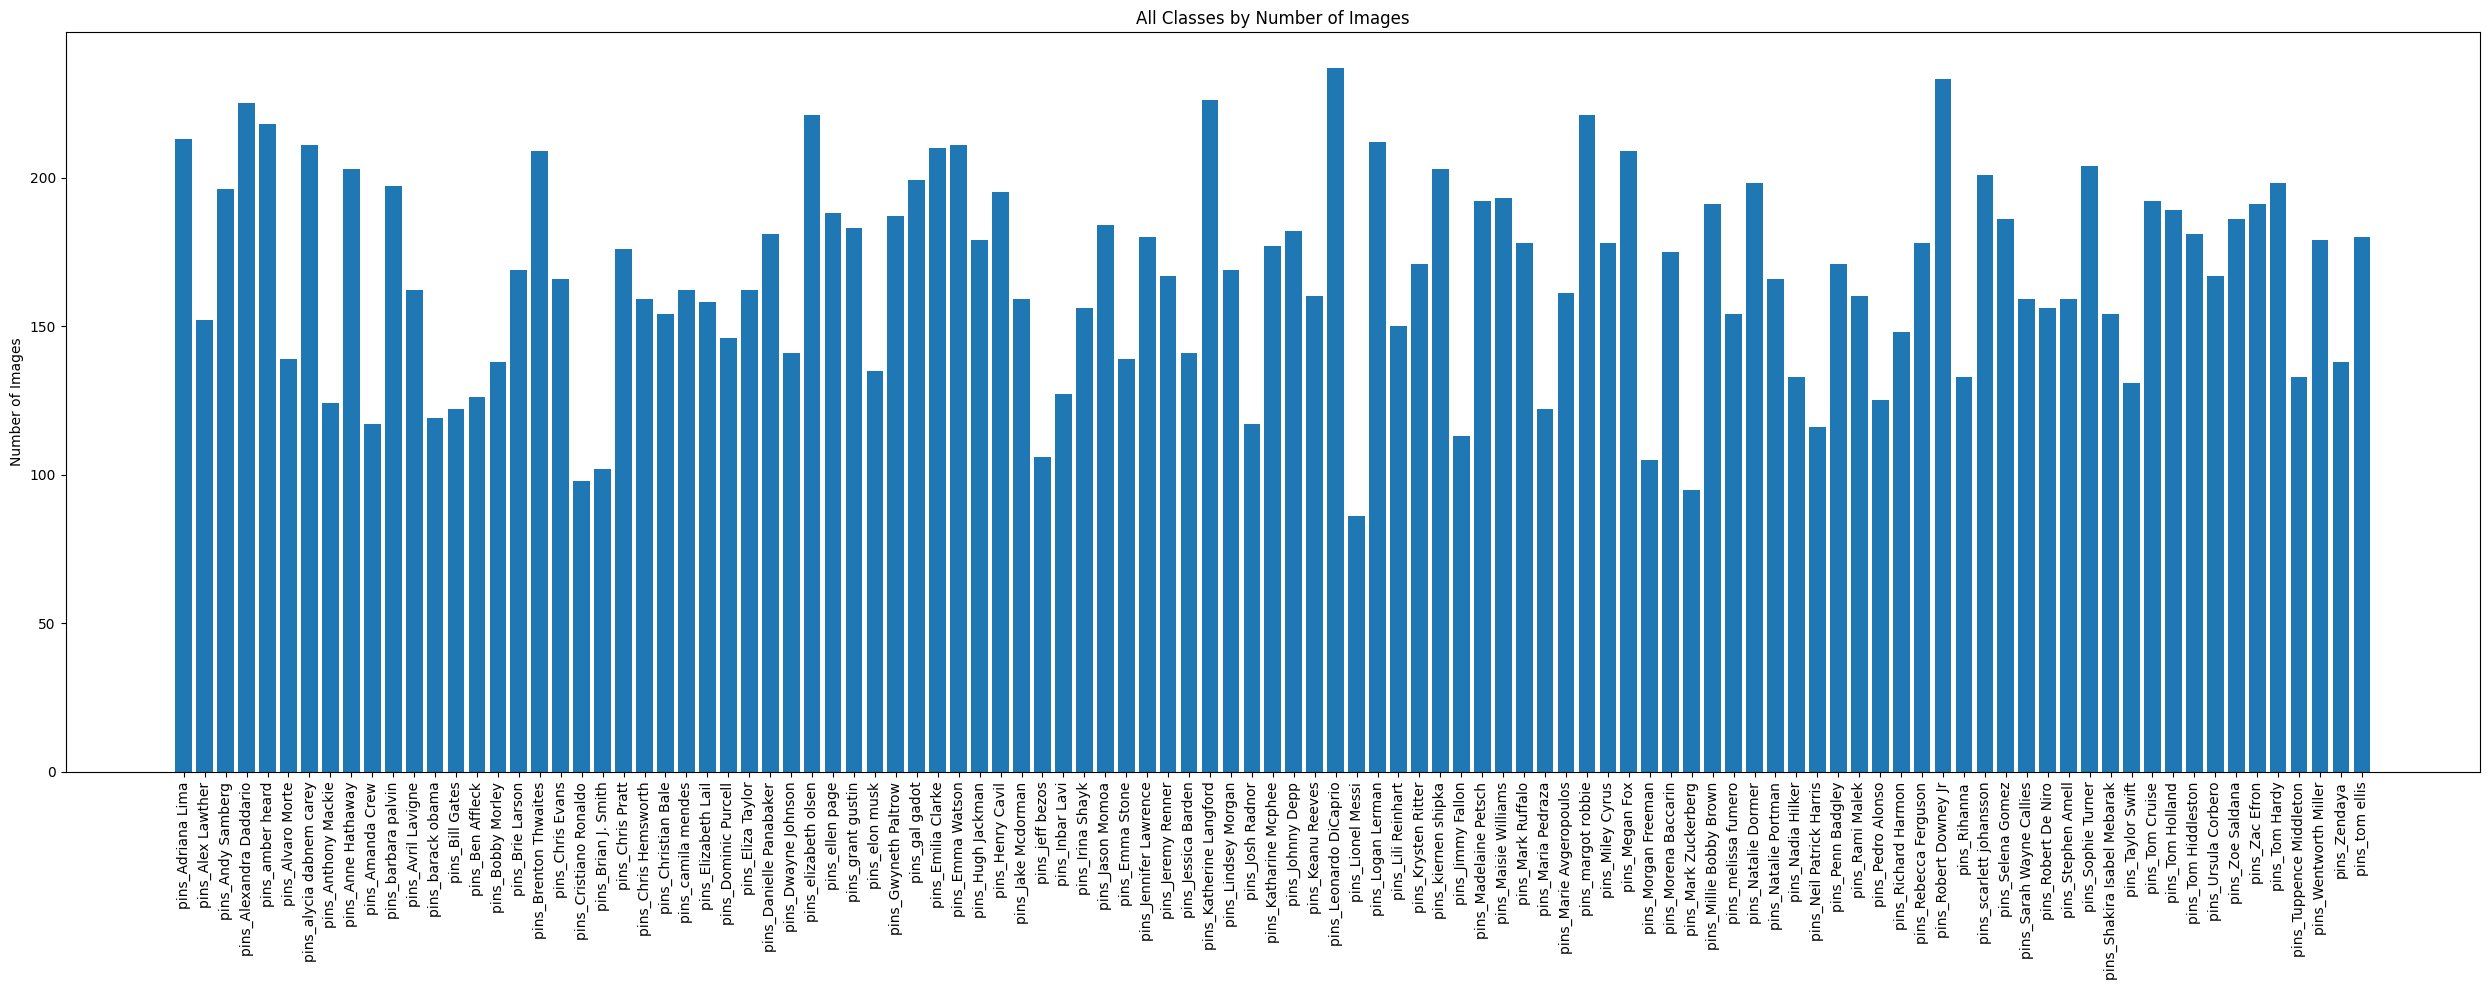

In [22]:
class_counts = {
    cls: len(os.listdir(os.path.join(PINS_DIR, cls)))
    for cls in classes
}

plt.figure(figsize=(25,10))
plt.bar(list(class_counts.keys()), list(class_counts.values()))

plt.xticks(rotation=90)
plt.title("All Classes by Number of Images")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

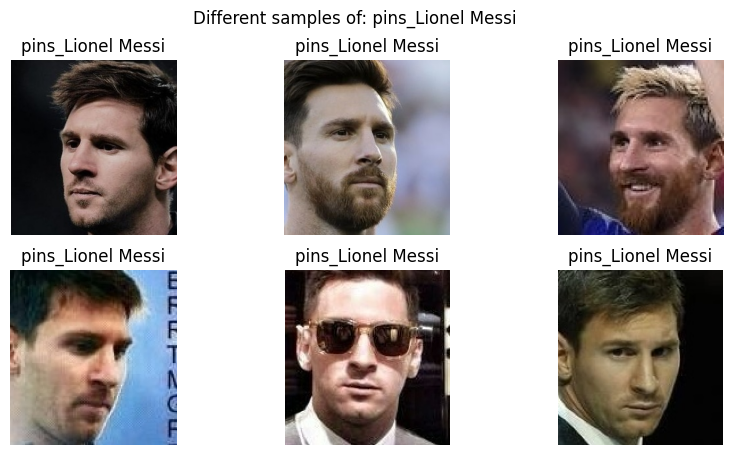

In [17]:
person = random.choice(classes)
images = os.listdir(os.path.join(PINS_DIR, person))

plt.figure(figsize=(10,5))

for i in range(6):
    img = Image.open(os.path.join(PINS_DIR, person, images[i]))
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(person)
    plt.axis("off")

plt.suptitle(f"Different samples of: {person}")
plt.show()

#Data Preprocessing

In [17]:
def generate_siamese_pairs(base_dir, num_pairs_per_class=40):
    anchor_paths = []
    validation_paths = []
    labels = []

    classes = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

    for current_class in classes:
        class_dir = os.path.join(base_dir, current_class)
        images = [os.path.join(class_dir, img) for img in os.listdir(class_dir)]

        if len(images) < 2: continue

        for _ in range(num_pairs_per_class):
            anc = random.choice(images)
            pos = random.choice(images)
            while anc == pos:
                pos = random.choice(images)

            anchor_paths.append(anc)
            validation_paths.append(pos)
            labels.append(1.0)

        other_classes = [c for c in classes if c != current_class]
        for _ in range(num_pairs_per_class):
            anc = random.choice(images)

            neg_class = random.choice(other_classes)
            neg_class_dir = os.path.join(base_dir, neg_class)
            neg_images = [os.path.join(neg_class_dir, img) for img in os.listdir(neg_class_dir)]

            neg = random.choice(neg_images)

            anchor_paths.append(anc)
            validation_paths.append(neg)
            labels.append(0.0)

    return anchor_paths, validation_paths, labels

anc_paths, val_paths, labels = generate_siamese_pairs(PINS_DIR, num_pairs_per_class=40)
print(f"Total dataset size: {len(labels)} pairs generated.")

def preprocess(file_path):
    byte_img = tf.io.read_file(file_path)
    img = tf.io.decode_jpeg(byte_img, channels=3)
    img = tf.image.resize(img, (100, 100))
    img = img / 255.0
    return img

def preprocess_twin(anc_path, val_path, label):
    return (preprocess(tf.convert_to_tensor(anc_path, dtype=tf.string)),
            preprocess(tf.convert_to_tensor(val_path, dtype=tf.string)),
            label)

dataset = tf.data.Dataset.from_tensor_slices((anc_paths, val_paths, labels))
dataset = dataset.map(preprocess_twin)
dataset = dataset.cache()
dataset = dataset.shuffle(buffer_size=len(labels))

train_size = int(len(labels) * 0.8)
val_size = len(labels) - train_size

train_data = dataset.take(train_size).batch(32).prefetch(tf.data.AUTOTUNE)
test_data = dataset.skip(train_size).take(val_size).batch(32).prefetch(tf.data.AUTOTUNE)
print("Data Pipeline is ready!")

Total dataset size: 8400 pairs generated.
Data Pipeline is ready!


#Train


In [18]:
def make_embedding():
    inp = Input(shape=(100,100,3), name='input_image')
    c1 = Conv2D(64, (10,10), activation='relu')(inp)
    m1 = MaxPooling2D(64, (2,2), padding='same')(c1)

    c2 = Conv2D(128, (7,7), activation='relu')(m1)
    m2 = MaxPooling2D(64, (2,2), padding='same')(c2)

    c3 = Conv2D(128, (4,4), activation='relu')(m2)
    m3 = MaxPooling2D(64, (2,2), padding='same')(c3)

    c4 = Conv2D(256, (4,4), activation='relu')(m3)
    f1 = Flatten()(c4)

    d1 = Dense(4096, activation=None)(f1)
    d1 = tf.keras.layers.BatchNormalization()(d1)

    return Model(inputs=inp, outputs=d1, name='embedding')

embedding = make_embedding()

def make_siamese_model():
    input_image = Input(name='input_img', shape=(100,100,3))
    validation_image = Input(name='validation_img', shape=(100,100,3))

    emb_a = embedding(input_image)
    emb_b = embedding(validation_image)

    distances = tf.keras.ops.abs(emb_a - emb_b)

    classifier = Dense(1, activation='sigmoid')(distances)

    return Model(inputs=[input_image, validation_image], outputs=classifier, name='SiameseNetwork')

siamese_model = make_siamese_model()
print("New Optimized Siamese Model Architecture created successfully!")

New Optimized Siamese Model Architecture created successfully!


In [19]:
from tensorflow.keras.metrics import BinaryAccuracy
import sys

binary_cross_loss = tf.losses.BinaryCrossentropy()
opt = tf.keras.optimizers.Adam(1e-5)
history = {'train_loss': [], 'train_acc': []}

@tf.function
def train_step(batch):
    X = batch[:2]
    y = batch[2]

    with tf.GradientTape() as tape:
        yhat = siamese_model(X, training=True)
        yhat = tf.squeeze(yhat, axis=-1)
        loss = binary_cross_loss(y, yhat)

    grad = tape.gradient(loss, siamese_model.trainable_variables)
    opt.apply_gradients(zip(grad, siamese_model.trainable_variables))

    return loss, yhat

def train(data, EPOCHS):
    checkpoint_dir = './training_checkpoints'
    checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt')
    checkpoint = tf.train.Checkpoint(opt=opt, siamese_model=siamese_model)

    total_batches = len(data)

    for epoch in range(1, EPOCHS+1):
        print(f'\nEpoch {epoch}/{EPOCHS}')

        progbar = tf.keras.utils.Progbar(
            target=total_batches,
            stateful_metrics=['accuracy', 'loss'],
            unit_name='step'
        )

        epoch_accuracy = BinaryAccuracy()
        epoch_loss = []

        for idx, batch in enumerate(data):
            loss, yhat = train_step(batch)

            epoch_accuracy.update_state(batch[2], yhat)
            current_loss = loss.numpy()
            epoch_loss.append(current_loss)
            current_acc = epoch_accuracy.result().numpy()

            progbar.update(
                idx + 1,
                values=[('accuracy', current_acc), ('loss', current_loss)]
            )

        history['train_loss'].append(np.mean(epoch_loss))
        history['train_acc'].append(epoch_accuracy.result().numpy())

        if epoch % 10 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

EPOCHS = 40
print("Starting Training Loop...")
train(train_data, EPOCHS)

Starting Training Loop...

Epoch 1/40
210/210 ━━━━━━━━━━━━━━━━━━━━ 1829s 424ms/step - accuracy: 0.4999 - loss: 0.7026

Epoch 2/40
210/210 ━━━━━━━━━━━━━━━━━━━━ 88s 421ms/step - accuracy: 0.5354 - loss: 0.7446

Epoch 3/40
210/210 ━━━━━━━━━━━━━━━━━━━━ 88s 420ms/step - accuracy: 0.5354 - loss: 0.6939

Epoch 4/40
210/210 ━━━━━━━━━━━━━━━━━━━━ 88s 420ms/step - accuracy: 0.5381 - loss: 0.7326

Epoch 5/40
210/210 ━━━━━━━━━━━━━━━━━━━━ 88s 421ms/step - accuracy: 0.5537 - loss: 0.7475

Epoch 6/40
210/210 ━━━━━━━━━━━━━━━━━━━━ 89s 422ms/step - accuracy: 0.5705 - loss: 0.7279

Epoch 7/40
210/210 ━━━━━━━━━━━━━━━━━━━━ 88s 421ms/step - accuracy: 0.5823 - loss: 0.6923

Epoch 8/40
210/210 ━━━━━━━━━━━━━━━━━━━━ 88s 421ms/step - accuracy: 0.5850 - loss: 0.6727

Epoch 9/40
210/210 ━━━━━━━━━━━━━━━━━━━━ 89s 421ms/step - accuracy: 0.5973 - loss: 0.6716

Epoch 10/40
210/210 ━━━━━━━━━━━━━━━━━━━━ 88s 421ms/step - accuracy: 0.6124 - loss: 0.6405

Epoch 11/40
210/210 ━━━━━━━━━━━━━━━━━━━━ 89s 422ms/step - accuracy: 0.

#Evaluate

In [20]:
print("\n Evaluating Model on Test Data...")
r = Recall()
p = Precision()

for test_input, test_val, y_true in test_data:
    yhat = siamese_model([test_input, test_val])
    r.update_state(y_true, yhat)
    p.update_state(y_true, yhat)

print(f"Final Test Metrics -> Recall: {r.result().numpy():.4f}, Precision: {p.result().numpy():.4f}")


 Evaluating Model on Test Data...
Final Test Metrics -> Recall: 0.9461, Precision: 0.9381



🔍 Evaluating Model on Test Data...

Final Test Accuracy:  0.9411
Final Test Recall:    0.9407
Final Test Precision: 0.9418



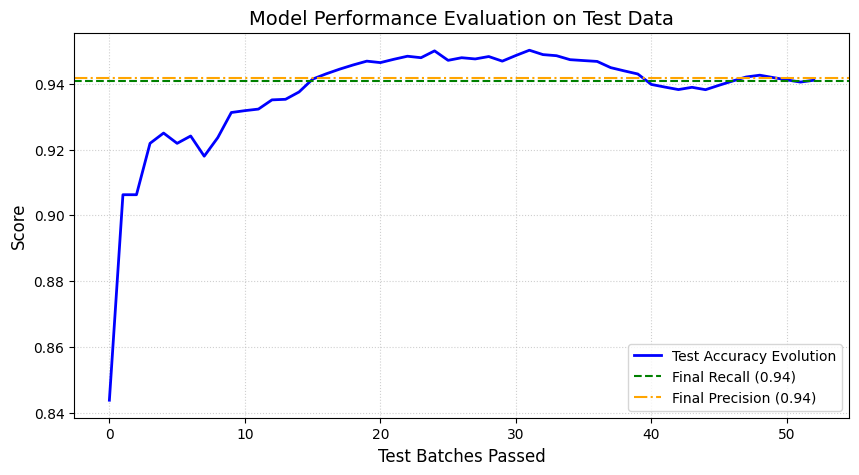

In [23]:
from tensorflow.keras.metrics import BinaryAccuracy

print("\n🔍 Evaluating Model on Test Data...")
r = Recall()
p = Precision()
acc = BinaryAccuracy()
test_losses = []
test_accs = []

for test_input, test_val, y_true in test_data:
    yhat = siamese_model([test_input, test_val])

    r.update_state(y_true, yhat)
    p.update_state(y_true, yhat)
    acc.update_state(y_true, yhat)

    test_accs.append(acc.result().numpy())

final_acc = acc.result().numpy()
final_recall = r.result().numpy()
final_precision = p.result().numpy()

print("\n" + "="*40)
print(f"Final Test Accuracy:  {final_acc:.4f}")
print(f"Final Test Recall:    {final_recall:.4f}")
print(f"Final Test Precision: {final_precision:.4f}")
print("="*40 + "\n")

plt.figure(figsize=(10, 5))

plt.plot(test_accs, label='Test Accuracy Evolution', color='blue', linewidth=2)

plt.axhline(y=final_recall, color='green', linestyle='--', label=f'Final Recall ({final_recall:.2f})')
plt.axhline(y=final_precision, color='orange', linestyle='-.', label=f'Final Precision ({final_precision:.2f})')

plt.title('Model Performance Evaluation on Test Data', fontsize=14)
plt.xlabel('Test Batches Passed', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

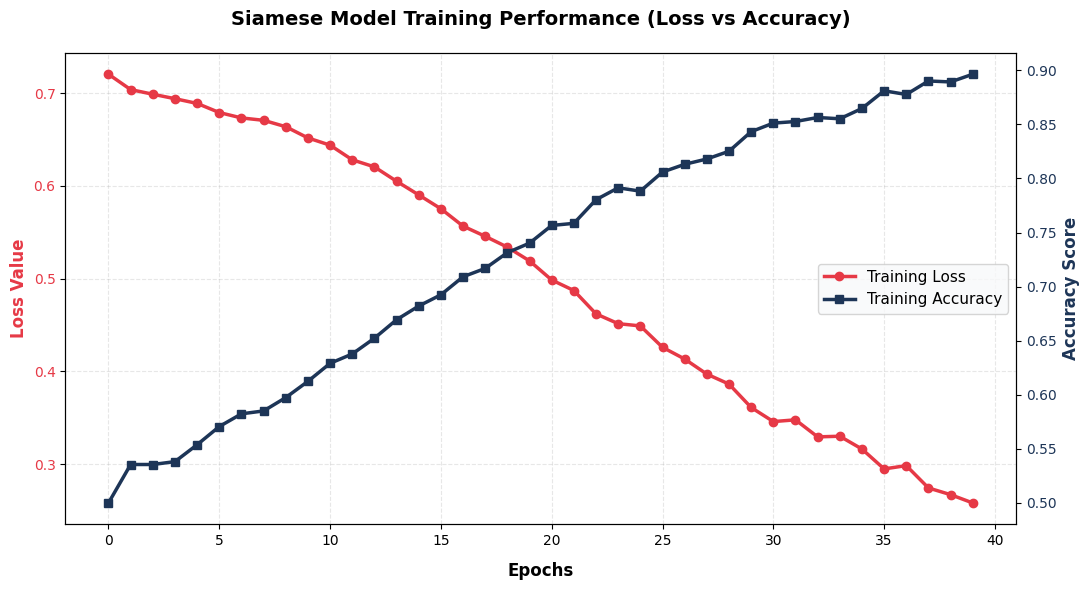

In [24]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(11, 6))

color_loss = '#E63946'
ax1.set_xlabel('Epochs', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('Loss Value', color=color_loss, fontsize=12, fontweight='bold')
line1 = ax1.plot(history['train_loss'], color=color_loss, linewidth=2.5, marker='o', label='Training Loss')
ax1.tick_params(axis='y', labelcolor=color_loss)
ax1.grid(True, linestyle='--', alpha=0.3)

ax2 = ax1.twinx()
color_acc = '#1D3557'
ax2.set_ylabel('Accuracy Score', color=color_acc, fontsize=12, fontweight='bold')
line2 = ax2.plot(history['train_acc'], color=color_acc, linewidth=2.5, marker='s', label='Training Accuracy')
ax2.tick_params(axis='y', labelcolor=color_acc)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', fontsize=11, frameon=True, facecolor='#F8F9FA')

plt.title('Siamese Model Training Performance (Loss vs Accuracy)', fontsize=14, fontweight='bold', pad=20)
fig.tight_layout()

plt.show()

#Save Model

In [21]:
siamese_model.save('/content/final_siamese_model.h5')
print("Model saved successfully as /content/final_siamese_model.h5")

Model saved successfully as /content/final_siamese_model.h5


#Convert the Model to TFlite

In [22]:
import tensorflow as tf

embedding_model = siamese_model.get_layer('embedding')

converter = tf.lite.TFLiteConverter.from_keras_model(embedding_model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

print("Converting H5 Embedding Model to TFLite...")
tflite_model = converter.convert()

tflite_save_path = "face_recognition_model.tflite"
with open(tflite_save_path, "wb") as f:
    f.write(tflite_model)

print(f"Conversion Complete! File saved as: {tflite_save_path}")

Converting H5 Embedding Model to TFLite...
Saved artifact at '/tmp/tmpipija1wy'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 4096), dtype=tf.float32, name=None)
Captures:
  138896586407568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138896586404880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138896586404688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138896586407184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138896586406032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138896586405648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138896586405072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138896439201808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138896439200656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138896439201424: TensorSpec(shape=(), d